# 01 — Synthetic Animal Insertion & Detection Evaluation

**Edge Case Dataset for Autonomous Driving**

| Component | Detail |
|-----------|--------|
| **Generator** | SDXL Inpainting (`diffusers/stable-diffusion-xl-1.0-inpainting-0.1`) |
| **ControlNet** | SDXL Depth (`diffusers/controlnet-depth-sdxl-1.0`) |
| **Segmentation** | SAM 3 (`facebook/sam3`) — road mask via automatic concept segmentation |
| **Depth** | Depth Anything V2 Small (`depth-anything/Depth-Anything-V2-Small-hf`) |
| **Precision** | `torch.float16` with fp16-fix VAE (A100 optimized) |
| **GPU** | NVIDIA A100 (80 GB) — native CUDA, no CPU offloading |

**Pipeline Steps:**
1. **Letterboxing** — Pad KITTI images to 1024×1024 (black pixel padding, no distortion)
2. **Road Segmentation** — SAM 3 (Meta) for high-quality road mask generation
3. **Depth Estimation** — Depth Anything V2 Small for fast, accurate depth maps
4. **SDXL Inpainting + ControlNet Depth** — Insert realistic animals with negative prompt control
5. **Manual Labeling** — ipywidgets tool for Good/Medium/Bad tagging
6. **Synthetic Detection** — Three detectors (Spectral/S-DiFL, CLIP/MTKT, ViT/HF)
7. **Evaluation & Ensemble** — AUC, Accuracy, F1 with Mean/Max/Min voting
8. **Export** — Zip YOLO dataset + CSV metrics to Google Drive

**I/O Protocol:** All processing on `/content/` (local Colab disk). Drive mounted only at the end.

---
## 0. Environment Setup

In [ ]:
%%capture
!pip install diffusers>=0.31.0 transformers accelerate safetensors sentencepiece
!pip install controlnet-aux timm
!pip install ultralytics opencv-python-headless Pillow
!pip install scikit-learn ipywidgets matplotlib seaborn pandas tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/datasets/kitti

print("Syncing KITTI dataset to local disk for optimized I/O performance...")
!cp -av /content/drive/MyDrive/Autonomous_Car/kitti_baseline/. /content/datasets/kitti/

# ======================== DATA PARTITIONING ========================
# Train Pool  = 100% of original KITTI train folder
# Val Pool    = 50% of original KITTI val folder  (random_state=42)
# Test Pool   = 50% of original KITTI val folder  (random_state=42)
# ===================================================================

import glob
import os
from sklearn.model_selection import train_test_split

KITTI_DIR = "/content/datasets/kitti"

# Discover original splits
train_images = sorted(glob.glob(os.path.join(KITTI_DIR, "images", "train", "*.png")))
val_images   = sorted(glob.glob(os.path.join(KITTI_DIR, "images", "val", "*.png")))

print(f"Original KITTI train: {len(train_images)} images")
print(f"Original KITTI val:   {len(val_images)} images")

# Split original val 50/50 into our val and test pools
val_pool, test_pool = train_test_split(
    val_images, test_size=0.5, random_state=42
)

# Train pool = 100% of original train
train_pool = train_images

# Integrity check: no leakage
train_stems = {os.path.basename(p) for p in train_pool}
val_stems   = {os.path.basename(p) for p in val_pool}
test_stems  = {os.path.basename(p) for p in test_pool}

assert len(train_stems & val_stems) == 0,  "LEAKAGE: train ∩ val"
assert len(train_stems & test_stems) == 0, "LEAKAGE: train ∩ test"
assert len(val_stems & test_stems) == 0,   "LEAKAGE: val ∩ test"
assert len(val_stems) + len(test_stems) == len(val_images), "val+test must equal original val"

# Store as a dict for split-aware iteration
SPLIT_POOLS = {
    "train": sorted(train_pool),
    "val":   sorted(val_pool),
    "test":  sorted(test_pool),
}

print(f"\n--- Internal Triple-Split ---")
for split, pool in SPLIT_POOLS.items():
    print(f"  {split:5s}: {len(pool)} images")
print("No data leakage detected. Integrity OK.")

In [ ]:
import os
import glob
import json
import random
import shutil
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
from PIL import Image
from tqdm.auto import tqdm

from dotenv import load_dotenv
from huggingface_hub import login


# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

load_dotenv('/content/drive/MyDrive/Autonomous_Car/.env')
hf_token = os.getenv("HF_TOKEN")

if hf_token:
    login(token=hf_token)
    os.environ["HUGGING_FACE_HUB_TOKEN"] = hf_token
    print("Authentication successful: Hugging Face access granted.")
else:
    print("WARNING: HF_TOKEN not found. Please ensure your .env file is correctly configured.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16   # fp16 for SDXL (with fp16-fix VAE)

print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {vram_gb:.1f} GB")
    print(f"Precision: float16")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authentication successful: Hugging Face access granted.
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Precision: float16


In [ ]:
# ======================== CONFIGURATION ========================

# --- Debug & Budget Control ---
DEBUG_MODE      = False
N_SAMPLES_TRAIN = 700
N_SAMPLES_VAL   = 150
N_SAMPLES_TEST  = 150

# --- SDXL Inpainting ---
N_STEPS            = 40
GUIDANCE_SCALE     = 8.5
STRENGTH           = 0.88
TARGET_SIZE        = 1024
ANIMAL_CLASS_ID    = 8
PADDING_MASK_CROP  = 160
RETRIES_PER_IMAGE  = 3

# Animal size in ORIGINAL image coordinates
MIN_ANIMAL_H = 90
MAX_ANIMAL_H = 180

NEGATIVE_PROMPT = (
    "deformed, blurry, low quality, distorted, cropped, cut off, partial animal, "
    "duplicate animal, extra legs, extra limbs, extra heads, bad anatomy, "
    "unrealistic pose, floating, malformed body, cartoon, painting, illustration, "
    "cgi, fake fur, unrealistic shadow, bad proportions"
)

# --- Compute effective sample counts per split ---
if DEBUG_MODE:
    SAMPLES_PER_SPLIT = {"train": 3, "val": 3, "test": 3}
else:
    SAMPLES_PER_SPLIT = {
        "train": N_SAMPLES_TRAIN,
        "val":   N_SAMPLES_VAL,
        "test":  N_SAMPLES_TEST,
    }

# Clamp to pool size
for split in SAMPLES_PER_SPLIT:
    pool_size = len(SPLIT_POOLS[split])
    if SAMPLES_PER_SPLIT[split] > pool_size:
        print(f"WARNING: {split} requested {SAMPLES_PER_SPLIT[split]} but pool has {pool_size}. Clamping.")
        SAMPLES_PER_SPLIT[split] = pool_size

# --- Sample images from each pool (reproducible) ---
SAMPLED_SPLITS = {}
for split, pool in SPLIT_POOLS.items():
    n = SAMPLES_PER_SPLIT[split]
    sampled = random.Random(42).sample(pool, n)
    SAMPLED_SPLITS[split] = sorted(sampled)

# --- Paths (all on local Colab disk) ---
LB_DIR      = "/content/letterboxed"
OUTPUT_DIR  = "/content/generated"
MASKS_DIR   = "/content/masks"
DEPTH_DIR   = "/content/depth"
RESULTS_DIR = "/content/results"

for d in [LB_DIR, OUTPUT_DIR, MASKS_DIR, DEPTH_DIR]:
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(d, "images", split), exist_ok=True)
        os.makedirs(os.path.join(d, "labels", split), exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

ANIMAL_PROMPTS = [
    "A realistic full-body stag with large antlers, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the road, side view, natural proportions, detailed fur, realistic contact shadow, daytime",
    "A realistic full-body brown moose, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the road, side view, natural proportions, detailed fur, realistic contact shadow, daytime",
    "A realistic full-body wild boar, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the asphalt, side view, natural proportions, detailed fur, realistic contact shadow, daytime",
    "A realistic full-body red fox, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the road, side view, natural proportions, detailed fur, realistic contact shadow, daytime",
    "A realistic full-body German Shepherd dog, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the road, side view, natural proportions, detailed fur, realistic contact shadow, daytime",
    "A realistic full-body raccoon, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the asphalt, side view, natural proportions, detailed fur, realistic contact shadow, daytime",
    "A realistic full-body grey wolf, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the road, side view, natural proportions, detailed fur, realistic contact shadow, daytime",
    "A realistic full-body white sheep, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the road, side view, natural proportions, detailed wool, realistic contact shadow, daytime",
    "A realistic full-body goat, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the roadside, side view, natural proportions, detailed fur, realistic contact shadow, daytime",
    "A realistic full-body ram with curved horns, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the roadside, side view, natural proportions, detailed wool, realistic contact shadow, daytime",
    "A realistic full-body cow, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the road, side view, natural proportions, detailed coat texture, realistic contact shadow, daytime",
    "A realistic full-body roe deer, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the roadside, side view, natural proportions, detailed fur, realistic contact shadow, daytime",
    "A realistic full-body fallow deer, clearly visible, centered in the masked area, appropriately scaled for the road scene, standing on the roadside, side view, natural proportions, detailed fur, realistic contact shadow, daytime",
]

# height / width
ANIMAL_ASPECT_RATIOS = {
    0: 1.1,   # stag
    1: 1.0,   # moose
    2: 0.65,  # boar
    3: 0.9,   # fox
    4: 1.0,   # dog
    5: 0.85,  # raccoon
    6: 1.05,  # bear
    7: 1.15,  # wolf
    8: 0.8,   # sheep
    9: 0.9,   # goat
    10: 0.85, # ram
    11: 0.95, # cow
    12: 0.9,  # calf
    13: 1.1,  # horse
    14: 1.05, # donkey
    15: 1.05, # mule
    16: 1.1,  # coyote
    17: 1.1,  # jackal
    18: 1.0,  # roe deer
    19: 1.0,  # fallow deer
}

CLASS_NAMES = {
    0: "Car", 1: "Van", 2: "Truck", 3: "Pedestrian",
    4: "Person_sitting", 5: "Cyclist", 6: "Tram", 7: "Misc",
    ANIMAL_CLASS_ID: "Animal",
}

print(f"DEBUG_MODE: {DEBUG_MODE}")
print(f"Samples per split: {SAMPLES_PER_SPLIT}")
print(f"Total images to process: {sum(SAMPLES_PER_SPLIT.values())}")
print(f"Target resolution: {TARGET_SIZE}x{TARGET_SIZE}")
print(f"Retries per image: {RETRIES_PER_IMAGE}")
print("Configuration ready.")

DEBUG_MODE: False
Samples per split: {'train': 0, 'val': 150, 'test': 150}
Total images to process: 300
Target resolution: 1024x1024
Retries per image: 3
Configuration ready.


---
## 1. Preprocessing — Split-Aware Letterboxing (640×640)

Pad KITTI images (~1242×375) with black pixels to exactly 640×640, preserving the original aspect ratio. Labels are adjusted accordingly. Each image retains its **split identity** (train/val/test) throughout the pipeline.

In [ ]:
def letterbox(img, target=TARGET_SIZE, color=(0, 0, 0)):
    """Resize and pad image to target x target, preserving aspect ratio.

    Returns:
        padded: The letterboxed image (target x target x 3)
        scale:  Scale factor applied
        pad_top, pad_left: Padding offsets in pixels
    """
    h, w = img.shape[:2]
    scale = min(target / h, target / w)

    new_h = int(h * scale)
    new_w = int(w * scale)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    pad_top  = (target - new_h) // 2
    pad_bot  = target - new_h - pad_top
    pad_left = (target - new_w) // 2
    pad_right = target - new_w - pad_left

    padded = cv2.copyMakeBorder(
        resized, pad_top, pad_bot, pad_left, pad_right,
        cv2.BORDER_CONSTANT, value=color
    )
    return padded, scale, pad_top, pad_left


def adjust_yolo_labels(label_text, orig_h, orig_w, scale, pad_top, pad_left, target=TARGET_SIZE):
    """Adjust YOLO normalized labels after letterboxing."""
    adjusted = []
    for line in label_text.strip().split("\n"):
        if not line.strip():
            continue
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls_id = parts[0]
        cx, cy, bw, bh = map(float, parts[1:5])

        # Original pixel coords
        cx_px = cx * orig_w
        cy_px = cy * orig_h
        bw_px = bw * orig_w
        bh_px = bh * orig_h

        # Transform to letterboxed coords
        cx_new = (cx_px * scale + pad_left) / target
        cy_new = (cy_px * scale + pad_top) / target
        bw_new = (bw_px * scale) / target
        bh_new = (bh_px * scale) / target

        adjusted.append(f"{cls_id} {cx_new:.6f} {cy_new:.6f} {bw_new:.6f} {bh_new:.6f}")

    return "\n".join(adjusted)


# Quick test
dummy = np.zeros((375, 1242, 3), dtype=np.uint8)
out, s, pt, pl = letterbox(dummy)
print(f"Input: {dummy.shape} -> Output: {out.shape}")
print(f"Scale: {s:.4f}, Pad top: {pt}, Pad left: {pl}")
assert out.shape == (1024, 1024, 3), "Letterbox output must be 640x640!"

Input: (375, 1242, 3) -> Output: (1024, 1024, 3)
Scale: 0.8245, Pad top: 357, Pad left: 0


In [ ]:
# Apply letterboxing across all three splits and populate lb_meta
lb_meta = {}

for split, img_paths in SAMPLED_SPLITS.items():
    lb_img_dir = os.path.join(LB_DIR, "images", split)
    lb_lbl_dir = os.path.join(LB_DIR, "labels", split)
    lb_meta[split] = []

    if split == "train":
        src_lbl_dir = os.path.join(KITTI_DIR, "labels", "train")
    else:
        src_lbl_dir = os.path.join(KITTI_DIR, "labels", "val")

    for img_path in tqdm(img_paths, desc=f"Letterboxing [{split}]"):
        stem = os.path.splitext(os.path.basename(img_path))[0]

        img = cv2.imread(img_path)
        if img is None:
            continue

        orig_h, orig_w = img.shape[:2]
        orig_img = img.copy()

        lb_img, scale, pad_top, pad_left = letterbox(img, TARGET_SIZE)

        if not DEBUG_MODE:
            cv2.imwrite(os.path.join(lb_img_dir, f"{stem}.png"), lb_img)

            lbl_path = os.path.join(src_lbl_dir, f"{stem}.txt")
            if os.path.exists(lbl_path):
                with open(lbl_path) as f:
                    label_text = f.read()
                adjusted = adjust_yolo_labels(
                    label_text, orig_h, orig_w, scale, pad_top, pad_left, TARGET_SIZE
                )
                with open(os.path.join(lb_lbl_dir, f"{stem}.txt"), "w") as f:
                    f.write(adjusted)

        lb_meta[split].append({
            "stem": stem,
            "split": split,
            "img_path": img_path,
            "orig_h": orig_h,
            "orig_w": orig_w,
            "scale": scale,
            "pad_top": pad_top,
            "pad_left": pad_left,
            "orig_img": orig_img,
            "lb_img": lb_img,
        })

print(f"\nDone! lb_meta created with {sum(len(v) for v in lb_meta.values())} images.")

Letterboxing [train]:   0%|          | 0/700 [00:00<?, ?it/s]

Letterboxing [val]:   0%|          | 0/150 [00:00<?, ?it/s]

Letterboxing [test]:   0%|          | 0/150 [00:00<?, ?it/s]


Done! lb_meta created with 1000 images.


In [ ]:
def project_to_letterbox(arr, meta, interp=cv2.INTER_LINEAR):
    """
    Project a 2D array from original image coordinates into the letterboxed canvas.
    """
    true_h = int(meta["orig_h"] * meta["scale"])
    true_w = int(meta["orig_w"] * meta["scale"])

    resized = cv2.resize(arr, (true_w, true_h), interpolation=interp)

    canvas = np.zeros((TARGET_SIZE, TARGET_SIZE), dtype=resized.dtype)
    pt, pl = meta["pad_top"], meta["pad_left"]
    canvas[pt:pt + true_h, pl:pl + true_w] = resized
    return canvas


def orig_to_lb_xy(x, y, meta):
    """
    Convert a point from original image coordinates to letterboxed coordinates.
    """
    x_lb = int(round(x * meta["scale"] + meta["pad_left"]))
    y_lb = int(round(y * meta["scale"] + meta["pad_top"]))
    return x_lb, y_lb

---
## 2. Road Segmentation (SAM 3 — Meta)

Uses **SAM 3** (`facebook/sam3`) with text-prompted concept segmentation to extract the road surface. The road is identified as the **largest mask in the lower half** of the image, queried via the text prompt `"road"`.

In [ ]:
from transformers import Sam3Model, Sam3Processor

sam3_model = Sam3Model.from_pretrained("facebook/sam3").to(DEVICE)
sam3_processor = Sam3Processor.from_pretrained("facebook/sam3")

print(f"SAM 3 loaded on {DEVICE}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

SAM 3 loaded on cuda


Road Segmentation [train]:   0%|          | 0/700 [00:00<?, ?it/s]

  [train] 700 masks -> /content/masks/images/train


Road Segmentation [val]:   0%|          | 0/150 [00:00<?, ?it/s]

  [val] 150 masks -> /content/masks/images/val


Road Segmentation [test]:   0%|          | 0/150 [00:00<?, ?it/s]

  [test] 150 masks -> /content/masks/images/test


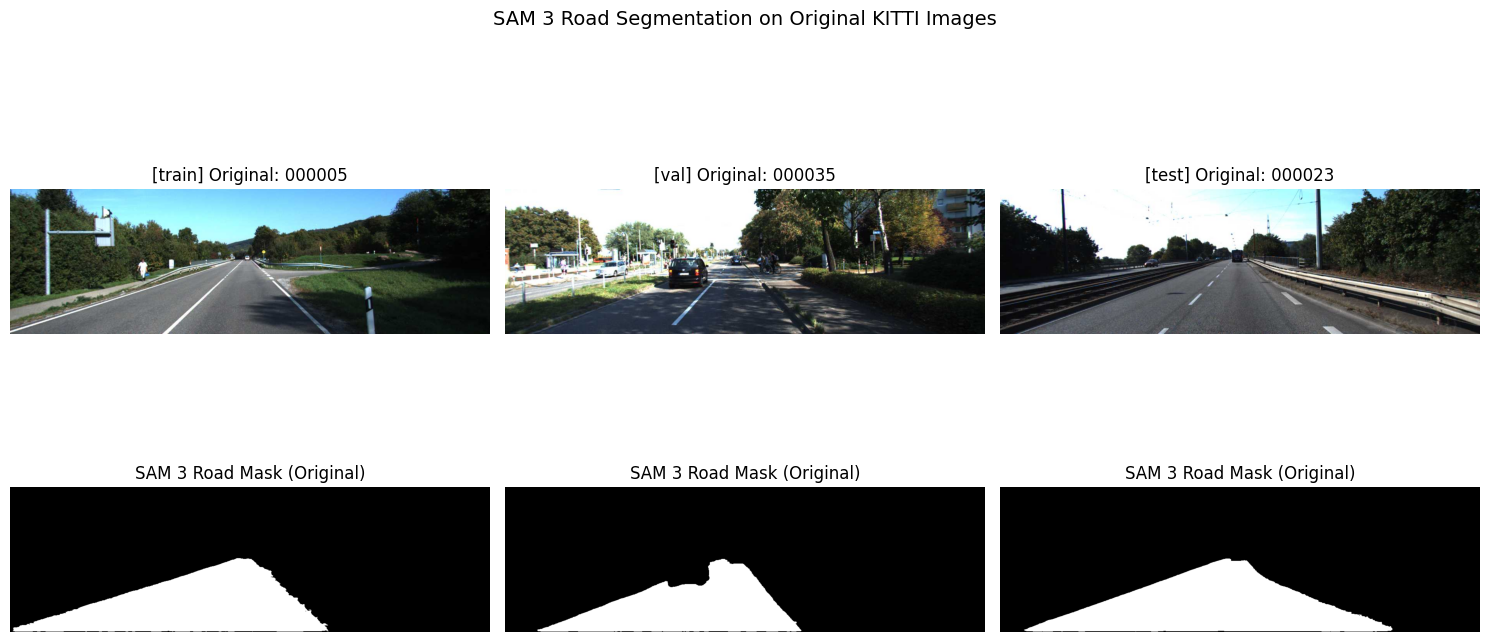

In [ ]:
def get_road_mask_sam3(image_pil, model, processor, device=DEVICE):
    """
    Extract road mask using SAM 3 text-prompted concept segmentation.
    """
    w, h = image_pil.size

    inputs = processor(images=image_pil, text="road", return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=0.3,
        mask_threshold=0.5,
        target_sizes=inputs.get("original_sizes").tolist()
    )[0]

    masks = results["masks"]
    scores = results["scores"]

    best_mask = None
    best_area = 0

    for mask_tensor, score in zip(masks, scores):
        mask_np = mask_tensor.cpu().numpy().astype(np.uint8)

        ys, xs = np.where(mask_np > 0)
        if len(ys) == 0:
            continue

        centroid_y = ys.mean()
        area = len(ys)

        if centroid_y > h * 0.4 and area > best_area:
            best_area = area
            best_mask = mask_np

    if best_mask is None:
        for mask_tensor in masks:
            mask_np = mask_tensor.cpu().numpy().astype(np.uint8)
            area = mask_np.sum()
            if area > best_area:
                best_area = area
                best_mask = mask_np

    if best_mask is None:
        return np.zeros((h, w), dtype=np.uint8)

    return best_mask * 255


# Generate road masks from ORIGINAL images, then project to letterbox
for split, metas in lb_meta.items():
    mask_img_dir = os.path.join(MASKS_DIR, "images", split)

    for meta in tqdm(metas, desc=f"Road Segmentation [{split}]"):
        stem = meta["stem"]

        img_pil = Image.fromarray(cv2.cvtColor(meta["orig_img"], cv2.COLOR_BGR2RGB))
        road_mask_orig = get_road_mask_sam3(img_pil, sam3_model, sam3_processor)

        road_mask_lb = project_to_letterbox(
            road_mask_orig, meta, interp=cv2.INTER_NEAREST
        )

        if not DEBUG_MODE:
            cv2.imwrite(os.path.join(mask_img_dir, f"{stem}_mask.png"), road_mask_lb)

        meta["road_mask_orig"] = road_mask_orig
        meta["road_mask"] = road_mask_lb

    print(f"  [{split}] {len(metas)} masks" + (" (in-memory)" if DEBUG_MODE else f" -> {mask_img_dir}"))

# Visualization
fig, axes = plt.subplots(2, len(lb_meta), figsize=(5 * len(lb_meta), 8))
if len(lb_meta) == 1:
    axes = axes[:, np.newaxis]

for col, (split, metas) in enumerate(lb_meta.items()):
    meta = metas[0]
    rgb = cv2.cvtColor(meta["orig_img"], cv2.COLOR_BGR2RGB)

    axes[0, col].imshow(rgb)
    axes[0, col].set_title(f"[{split}] Original: {meta['stem']}")
    axes[0, col].axis("off")

    axes[1, col].imshow(meta["road_mask_orig"], cmap="gray")
    axes[1, col].set_title("SAM 3 Road Mask (Original)")
    axes[1, col].axis("off")

plt.suptitle("SAM 3 Road Segmentation on Original KITTI Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Free SAM 3 from GPU
del sam3_model, sam3_processor
torch.cuda.empty_cache()
gc.collect()
print("SAM 3 unloaded.")

SAM 3 unloaded.


---
## 3. Depth Estimation (Depth Anything V2 Small)

Uses **Depth Anything V2 Small** (`depth-anything/Depth-Anything-V2-Small-hf`) — lightweight, fast, and highly accurate monocular depth estimation. Output is used both as ControlNet conditioning for SDXL and for perspective-aware animal sizing.

In [ ]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

DEPTH_MODEL_ID = "depth-anything/Depth-Anything-V2-Small-hf"

depth_processor = AutoImageProcessor.from_pretrained(DEPTH_MODEL_ID)
depth_model = AutoModelForDepthEstimation.from_pretrained(
    DEPTH_MODEL_ID
).to(DEVICE).eval()

print(f"Depth Anything V2 Small loaded on {DEVICE}")

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Depth Anything V2 Small loaded on cuda


In [ ]:
def get_depth_map(image_pil, model, processor):
    """
    Inference for Depth Anything V2 on the ORIGINAL image.
    Returns a uint8 depth map in the same size as the input image.
    """
    inputs = processor(images=image_pil, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        depth = outputs.predicted_depth

    prediction = torch.nn.functional.interpolate(
        depth.unsqueeze(1),
        size=image_pil.size[::-1],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

    depth_np = prediction.cpu().numpy()

    d_min = depth_np.min()
    d_max = depth_np.max()
    depth_norm = (depth_np - d_min) / (d_max - d_min + 1e-8)
    depth_norm = (depth_norm * 255).astype(np.uint8)

    return depth_norm

Depth Estimation [train]:   0%|          | 0/700 [00:00<?, ?it/s]

  [train] Successfully processed 700 depth maps.


Depth Estimation [val]:   0%|          | 0/150 [00:00<?, ?it/s]

  [val] Successfully processed 150 depth maps.


Depth Estimation [test]:   0%|          | 0/150 [00:00<?, ?it/s]

  [test] Successfully processed 150 depth maps.


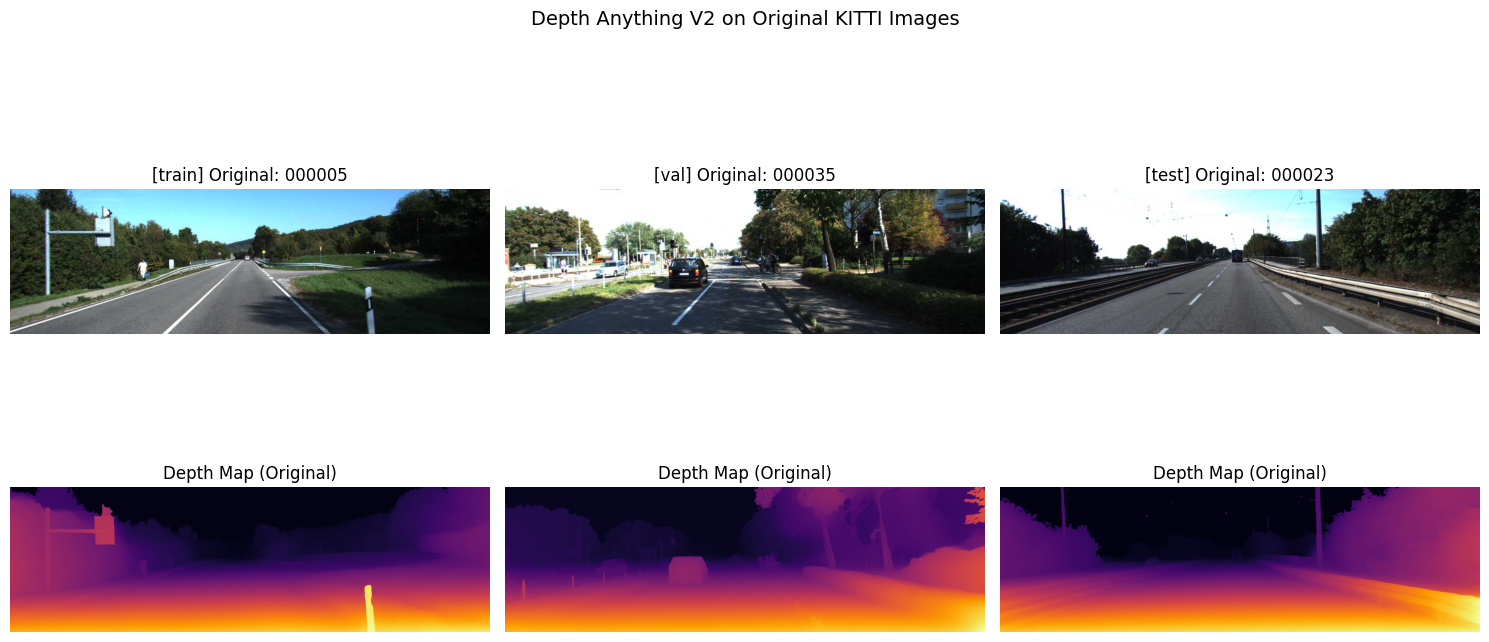

In [ ]:
# =================================================================
# Main Depth Estimation Loop with Visualization
# =================================================================
for split, metas in lb_meta.items():
    depth_img_dir = os.path.join(DEPTH_DIR, "images", split)

    for meta in tqdm(metas, desc=f"Depth Estimation [{split}]"):
        stem = meta["stem"]

        img_pil = Image.fromarray(cv2.cvtColor(meta["orig_img"], cv2.COLOR_BGR2RGB))
        depth_map_orig = get_depth_map(img_pil, depth_model, depth_processor)

        depth_map_lb = project_to_letterbox(
            depth_map_orig, meta, interp=cv2.INTER_LINEAR
        )

        if not DEBUG_MODE:
            cv2.imwrite(os.path.join(depth_img_dir, f"{stem}_depth.png"), depth_map_lb)

        meta["depth_map_orig"] = depth_map_orig
        meta["depth_map"] = depth_map_lb

    print(f"  [{split}] Successfully processed {len(metas)} depth maps.")

# Visualization
n_splits = len(lb_meta)
fig, axes = plt.subplots(2, n_splits, figsize=(5 * n_splits, 8))

if n_splits == 1:
    axes = axes[:, np.newaxis]

for col, (split, metas) in enumerate(lb_meta.items()):
    if not metas:
        continue

    meta = metas[0]
    rgb = cv2.cvtColor(meta["orig_img"], cv2.COLOR_BGR2RGB)

    axes[0, col].imshow(rgb)
    axes[0, col].set_title(f"[{split}] Original: {meta['stem']}")
    axes[0, col].axis("off")

    axes[1, col].imshow(meta["depth_map_orig"], cmap="inferno")
    axes[1, col].set_title("Depth Map (Original)")
    axes[1, col].axis("off")

plt.suptitle("Depth Anything V2 on Original KITTI Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Free Depth model from GPU
del depth_model, depth_processor
torch.cuda.empty_cache()
gc.collect()
print("Depth Anything V2 unloaded.")

Depth Anything V2 unloaded.


---
## 4. SDXL Inpainting + ControlNet Depth — Animal Insertion

Uses **SDXL Inpainting** (`diffusers/stable-diffusion-xl-1.0-inpainting-0.1`) with **ControlNet Depth SDXL** (`diffusers/controlnet-depth-sdxl-1.0`).

- **Precision:** `float16` with `sdxl-vae-fp16-fix` (no NaN issues)
- **Execution:** Native CUDA on A100
- **Negative prompt:** Prevents deformations, blur, and artifacts
- **Mask algorithm:** Depth-aware sizing with per-animal aspect ratios and edge-clamping

In [ ]:
from diffusers import StableDiffusionXLInpaintPipeline, AutoencoderKL

# fp16-fix VAE
vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix",
    torch_dtype=DTYPE,
)

pipe = StableDiffusionXLInpaintPipeline.from_pretrained(
    "diffusers/stable-diffusion-xl-1.0-inpainting-0.1",
    vae=vae,
    variant="fp16",
    use_safetensors=True,
    torch_dtype=DTYPE,
)

pipe.to(DEVICE)
pipe.enable_attention_slicing()
pipe.enable_vae_slicing()
pipe.set_progress_bar_config(disable=True)

print(f"SDXL Inpainting loaded on {DEVICE} (float16).")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

...

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--diffusers--stable-diffusion-xl-1.0-inpainting-0.1/snapshots/115134f363124c53c7d878647567d04daf26e41e/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--diffusers--stable-diffusion-xl-1.0-inpainting-0.1/snapshots/115134f363124c53c7d878647567d04daf26e41e/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


SDXL Inpainting loaded on cuda (float16).
VRAM used: 7.2 GB


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLInpaintPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [ ]:
def create_animal_mask(meta, prompt_idx, target=TARGET_SIZE, context_padding=0.18):
    """
    Create a tighter, animal-shaped inpainting mask on ORIGINAL coordinates,
    then project it into the letterboxed canvas.
    """
    road_mask = meta["road_mask_orig"]
    depth_map = meta["depth_map_orig"]

    h0, w0 = road_mask.shape
    aspect_ratio = ANIMAL_ASPECT_RATIOS.get(prompt_idx, 1.0)

    valid = road_mask.copy()

    # Keep only realistic lower image region
    valid[:int(h0 * 0.45), :] = 0
    valid[:, :int(w0 * 0.08)] = 0
    valid[:, int(w0 * 0.92):] = 0

    # Avoid thin borders and noisy edges
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    valid = cv2.erode(valid, kernel, iterations=1)

    road_pixels = np.argwhere(valid > 0)
    if len(road_pixels) < 100:
        return None, None, None, prompt_idx

    # Bias placement toward lower rows so the animal is bigger and more visible
    ys = road_pixels[:, 0].astype(np.float32)
    weights = (ys - ys.min() + 1.0) ** 2
    weights /= weights.sum()

    chosen_idx = np.random.choice(len(road_pixels), p=weights)
    cy0, cx0 = road_pixels[chosen_idx]

    depth_val = float(depth_map[cy0, cx0]) / 255.0

    # Bigger animal than before
    animal_h0 = int(np.clip(MIN_ANIMAL_H + 120 * depth_val, MIN_ANIMAL_H, MAX_ANIMAL_H))
    animal_w0 = int(animal_h0 / aspect_ratio)

    # Tight intended bbox in ORIGINAL coordinates
    box_top0 = max(0, cy0 - animal_h0)
    box_bot0 = min(h0, cy0)
    box_left0 = max(0, cx0 - animal_w0 // 2)
    box_right0 = min(w0, cx0 + animal_w0 // 2)

    # Convert tight bbox to letterbox coordinates
    box_left, box_top = orig_to_lb_xy(box_left0, box_top0, meta)
    box_right, box_bot = orig_to_lb_xy(box_right0, box_bot0, meta)
    cx_lb, cy_lb = orig_to_lb_xy(cx0, cy0, meta)

    # Safety clamp
    box_left = max(0, min(target - 1, box_left))
    box_top = max(0, min(target - 1, box_top))
    box_right = max(0, min(target, box_right))
    box_bot = max(0, min(target, box_bot))

    if box_right <= box_left or box_bot <= box_top:
        return None, None, None, prompt_idx

    box_w = box_right - box_left
    box_h = box_bot - box_top

    # Build a softer, animal-like mask instead of a plain rectangle
    mask = np.zeros((target, target), dtype=np.uint8)

    pad_w = max(10, int(box_w * context_padding))
    pad_h = max(10, int(box_h * context_padding))

    body_cx = (box_left + box_right) // 2
    body_cy = int(box_top + 0.45 * box_h)

    axes_x = max(18, box_w // 2 + pad_w)
    axes_y = max(24, box_h // 2 + pad_h)

    # Main body
    cv2.ellipse(mask, (body_cx, body_cy), (axes_x, axes_y), 0, 0, 360, 255, -1)

    # Two lower leg/contact strips so the model sees "standing on road"
    leg_w = max(6, box_w // 10)
    leg_h = max(18, int(box_h * 0.28))
    leg_y1 = max(0, box_bot - leg_h)
    leg_y2 = min(target - 1, box_bot + max(8, pad_h // 2))

    leg_offset = max(10, box_w // 6)

    left_leg_x1 = max(0, body_cx - leg_offset - leg_w)
    left_leg_x2 = min(target - 1, body_cx - leg_offset + leg_w)

    right_leg_x1 = max(0, body_cx + leg_offset - leg_w)
    right_leg_x2 = min(target - 1, body_cx + leg_offset + leg_w)

    cv2.rectangle(mask, (left_leg_x1, leg_y1), (left_leg_x2, leg_y2), 255, -1)
    cv2.rectangle(mask, (right_leg_x1, leg_y1), (right_leg_x2, leg_y2), 255, -1)

    # Slight blur for softer inpainting transitions
    mask = cv2.GaussianBlur(mask, (21, 21), 0)

    bbox = (box_left, box_top, box_right, box_bot)
    center = (cx_lb, cy_lb)

    return mask, center, bbox, prompt_idx


def create_animal_yolo_label(bbox, class_id=ANIMAL_CLASS_ID, target=TARGET_SIZE):
    x1, y1, x2, y2 = bbox
    cx = ((x1 + x2) / 2) / target
    cy = ((y1 + y2) / 2) / target
    bw = (x2 - x1) / target
    bh = (y2 - y1) / target
    return f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"


print("Updated mask + label functions are ready.")

Updated mask + label functions are ready.


In [ ]:
# =================================================================
# Main Generation Loop (SDXL Inpainting - Optimized)
# =================================================================
import random
import matplotlib.pyplot as plt
import os
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

def masked_change_score(init_rgb_np, result_pil, mask_np):
    """
    Higher score = stronger change inside the masked area.
    Used to pick the best attempt among several seeds.
    """
    result_np = np.array(result_pil).astype(np.float32)
    init_np = init_rgb_np.astype(np.float32)

    mask_bool = mask_np > 20
    if mask_bool.sum() == 0:
        return -1.0

    diff = np.abs(result_np - init_np).mean(axis=2)
    return float(diff[mask_bool].mean())


for split, metas in lb_meta.items():


    gen_img_dir = os.path.join(OUTPUT_DIR, "images", split)
    gen_lbl_dir = os.path.join(OUTPUT_DIR, "labels", split)

    if not DEBUG_MODE:
        os.makedirs(gen_img_dir, exist_ok=True)
        os.makedirs(gen_lbl_dir, exist_ok=True)

    for meta in tqdm(metas, desc=f"Processing [{split}]"):
        stem = meta["stem"]
        output_img_path = os.path.join(gen_img_dir, f"{stem}.png")

        # 2) Optimization: Skip existing files to avoid redundant GPU work
        if not DEBUG_MODE and os.path.exists(output_img_path):
            continue

        # 3) Random animal prompt selection
        prompt_idx = random.randint(0, len(ANIMAL_PROMPTS) - 1)
        prompt = ANIMAL_PROMPTS[prompt_idx]

        # 4) Build mask for object placement
        mask, center, bbox, _ = create_animal_mask(
            meta=meta,
            prompt_idx=prompt_idx,
            context_padding=0.18
        )

        if mask is None:
            if DEBUG_MODE:
                print(f"  [WARNING] Skipping {stem}: No valid placement region found.")
            continue

        # 5) Prepare inputs for the pipeline
        init_image = Image.fromarray(cv2.cvtColor(meta["lb_img"], cv2.COLOR_BGR2RGB))
        init_rgb_np = np.array(init_image)
        mask_image = Image.fromarray(mask).convert("L")

        best_result = None
        best_seed = None
        best_score = -1.0

        # 6) Multiple attempts with different seeds to find the best integration
        for attempt in range(RETRIES_PER_IMAGE):
            seed = random.randint(0, 2**31 - 1)
            generator = torch.Generator(device=DEVICE).manual_seed(seed)

            with torch.no_grad():
                candidate = pipe(
                    prompt=prompt,
                    negative_prompt=NEGATIVE_PROMPT,
                    image=init_image,
                    mask_image=mask_image,
                    num_inference_steps=N_STEPS,
                    guidance_scale=GUIDANCE_SCALE,
                    strength=STRENGTH,
                    padding_mask_crop=PADDING_MASK_CROP,
                    generator=generator
                ).images[0]

            score = masked_change_score(init_rgb_np, candidate, mask)

            if score > best_score:
                best_score = score
                best_seed = seed
                best_result = candidate

        result_image = best_result

        # 7) Visualization (Only enabled in DEBUG_MODE to save memory/output space)
        if DEBUG_MODE:
            fig, ax = plt.subplots(1, 3, figsize=(18, 6))
            ax[0].imshow(init_image)
            ax[0].plot(center[0], center[1], "ro", markersize=8)
            ax[0].set_title(f"1. Original\n({center[0]}, {center[1]})")
            ax[0].axis("off")

            ax[1].imshow(mask, cmap="gray")
            ax[1].set_title(f"2. Mask\n{prompt.split(',')[0]}")
            ax[1].axis("off")

            ax[2].imshow(result_image)
            ax[2].set_title(f"3. Result\nSeed: {best_seed}")
            ax[2].axis("off")

            plt.tight_layout()
            plt.show()
            plt.close(fig) # Prevent memory leaks by closing the figure

        # 8) Save outputs
        if not DEBUG_MODE:
            result_image.save(output_img_path)
            yolo_label = create_animal_yolo_label(bbox, ANIMAL_CLASS_ID, TARGET_SIZE)
            with open(os.path.join(gen_lbl_dir, f"{stem}.txt"), "w") as f:
                f.write(yolo_label + "\n")

        # Update meta with the result for downstream tasks
        meta["gen_img"] = np.array(result_image)

print("\nGeneration process finished.")

Skipping 'train' split - already generated.


Processing [test]: 100%|██████████| 150/150 [55:03<00:00, 22.03s/it]


Generation process finished.


In [ ]:
# Free SDXL pipeline from GPU
del pipe, vae
torch.cuda.empty_cache()
gc.collect()
print("SDXL pipeline unloaded.")

SDXL pipeline unloaded.


In [ ]:
import os
import glob
import json
import numpy as np
import cv2
from PIL import Image

def strip_letterbox_pil(image_pil, black_threshold=8):
    """
    Remove black letterbox borders and keep only the actual image content.
    """
    img_np = np.array(image_pil)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    mask = gray > black_threshold
    coords = np.argwhere(mask)

    if len(coords) == 0:
        return image_pil

    y1, x1 = coords.min(axis=0)
    y2, x2 = coords.max(axis=0) + 1

    cropped = img_np[y1:y2, x1:x2]
    return Image.fromarray(cropped)


def yolo_to_xyxy(label_path, image_size=TARGET_SIZE):
    """
    Read the first YOLO box from a label file and convert to pixel xyxy.
    Assumes one inserted animal box per synthetic image.
    """
    if not os.path.exists(label_path):
        return None

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    if len(lines) == 0:
        return None

    parts = lines[0].split()
    if len(parts) < 5:
        return None

    _, cx, cy, bw, bh = parts[:5]
    cx, cy, bw, bh = map(float, [cx, cy, bw, bh])

    cx *= image_size
    cy *= image_size
    bw *= image_size
    bh *= image_size

    x1 = int(round(cx - bw / 2))
    y1 = int(round(cy - bh / 2))
    x2 = int(round(cx + bw / 2))
    y2 = int(round(cy + bh / 2))

    x1 = max(0, min(image_size - 1, x1))
    y1 = max(0, min(image_size - 1, y1))
    x2 = max(1, min(image_size, x2))
    y2 = max(1, min(image_size, y2))

    if x2 <= x1 or y2 <= y1:
        return None

    return (x1, y1, x2, y2)


def crop_roi_pil(image_pil, bbox, pad_ratio=0.35, min_crop=96):
    """
    Crop a padded ROI around the animal bbox.
    """
    if bbox is None:
        return strip_letterbox_pil(image_pil)

    img_np = np.array(image_pil)
    h, w = img_np.shape[:2]
    x1, y1, x2, y2 = bbox

    bw = x2 - x1
    bh = y2 - y1

    pad_x = int(bw * pad_ratio)
    pad_y = int(bh * pad_ratio)

    rx1 = max(0, x1 - pad_x)
    ry1 = max(0, y1 - pad_y)
    rx2 = min(w, x2 + pad_x)
    ry2 = min(h, y2 + pad_y)

    crop = img_np[ry1:ry2, rx1:rx2]

    if crop.shape[0] < min_crop or crop.shape[1] < min_crop:
        side = max(min_crop, crop.shape[0], crop.shape[1])
        canvas = np.zeros((side, side, 3), dtype=np.uint8)
        yoff = (side - crop.shape[0]) // 2
        xoff = (side - crop.shape[1]) // 2
        canvas[yoff:yoff+crop.shape[0], xoff:xoff+crop.shape[1]] = crop
        crop = canvas

    return Image.fromarray(crop)


def get_synthetic_samples():
    """
    Collect synthetic images from all splits with matching label paths.
    """
    samples = []
    for split in ["train", "val", "test"]:
        img_dir = os.path.join(OUTPUT_DIR, "images", split)
        lbl_dir = os.path.join(OUTPUT_DIR, "labels", split)

        for img_path in sorted(glob.glob(os.path.join(img_dir, "*.png"))):
            fname = os.path.basename(img_path)
            stem = os.path.splitext(fname)[0]
            lbl_path = os.path.join(lbl_dir, f"{stem}.txt")

            samples.append({
                "split": split,
                "id": f"{split}/{fname}",
                "img_path": img_path,
                "lbl_path": lbl_path,
                "fname": fname,
            })
    return samples

---
## 5. Manual Labeling Widget (ipywidgets)

Tag each generated image as **Good** (realistic), **Medium** (acceptable), or **Bad** (obvious artifacts). Labels are saved to JSON for evaluation.

In [ ]:
# ---------- Detector 1: Spectral Analysis (S-DiFL inspired) ----------

def spectral_score(image_np):
    """S-DiFL-inspired frequency analysis detector.

    Computes the ratio of mid-frequency to high-frequency energy in the
    2D FFT magnitude spectrum. Synthetic images from diffusion models
    exhibit distinct spectral fingerprints due to upsampling artifacts.

    Returns: float in [0, 1], higher = more likely synthetic.
    """
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY).astype(np.float32)

    # 2D FFT
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.log1p(np.abs(fshift))

    h, w = magnitude.shape
    cy, cx = h // 2, w // 2

    # Radial masks
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((Y - cy) ** 2 + (X - cx) ** 2)

    r_low = min(h, w) // 8
    r_mid = min(h, w) // 4

    low_energy = np.sum(magnitude[dist <= r_low])
    mid_energy = np.sum(magnitude[(dist > r_low) & (dist <= r_mid)])
    high_energy = np.sum(magnitude[dist > r_mid])

    # Synthetic images tend to have higher mid-to-high frequency ratio
    ratio = mid_energy / (high_energy + 1e-8)
    score = 1.0 / (1.0 + np.exp(-0.5 * (ratio - 2.0)))  # sigmoid
    return float(score)


# Quick test
test_img = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)
print(f"Spectral detector test score: {spectral_score(test_img):.4f}")

Spectral detector test score: 0.2873


In [ ]:
# ---------- Detector 2: CLIP-based ----------

from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-large-patch14",
    torch_dtype=DTYPE
).to(DEVICE).eval()

clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

CLIP_TEXTS = [
    "a real dashcam photograph of an urban or suburban road scene",
    "a road scene photograph edited with an inserted animal or AI-generated object"
]

def clip_score(image_pil):
    """
    Returns: float in [0, 1], higher = more likely synthetic.
    """
    inputs = clip_processor(
        text=CLIP_TEXTS,
        images=image_pil,
        return_tensors="pt",
        padding=True
    )
    inputs = {k: v.to(DEVICE) if hasattr(v, "to") else v for k, v in inputs.items()}

    with torch.no_grad():
        outputs = clip_model(**inputs)

    probs = outputs.logits_per_image.float().softmax(dim=1).cpu().numpy()[0]
    return float(probs[1])

print("CLIP detector loaded.")

In [ ]:
# ---------- Detector 3: ViT-based (HuggingFace pre-trained) ----------

from transformers import pipeline as hf_pipeline

vit_detector = hf_pipeline(
    "image-classification",
    model="umm-maybe/AI-image-detector",
    device=0 if DEVICE == "cuda" else -1,
)


def vit_score(image_pil):
    """HuggingFace ViT AI-image-detector.
    Returns: float in [0, 1], higher = more likely synthetic.
    """
    results = vit_detector(image_pil)
    for item in results:
        label = item["label"].lower()
        if "artificial" in label or "ai" in label or "fake" in label:
            return float(item["score"])
    # Fallback: 1 - P(real)
    for item in results:
        label = item["label"].lower()
        if "human" in label or "real" in label:
            return 1.0 - float(item["score"])
    return 0.5


print("ViT detector loaded.")

config.json:   0%|          | 0.00/937 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/348M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/347M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/240 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


ViT detector loaded.


In [ ]:
# ======== Run all detectors on real + synthetic images (split-aware, content-crop + ROI) ========

detection_records = []

for split in ["train", "val", "test"]:
    lb_img_dir  = os.path.join(LB_DIR, "images", split)
    gen_img_dir = os.path.join(OUTPUT_DIR, "images", split)
    gen_lbl_dir = os.path.join(OUTPUT_DIR, "labels", split)

    # ---------------- Real images ----------------
    real_images = sorted(glob.glob(os.path.join(lb_img_dir, "*.png")))
    print(f"[{split}] Scoring {len(real_images)} real images...")

    for img_path in tqdm(real_images, desc=f"Real [{split}]"):
        fname = os.path.basename(img_path)

        img_pil = Image.open(img_path).convert("RGB")
        content_pil = strip_letterbox_pil(img_pil)
        content_np = np.array(content_pil)

        detection_records.append({
            "id": f"{split}/{fname}",
            "filename": fname,
            "split": split,
            "is_synthetic": 0,
            "spectral_score": spectral_score(content_np),
            "vit_score": vit_score(content_pil),
            "spectral_roi_score": np.nan,
            "vit_roi_score": np.nan,
        })

    # ---------------- Synthetic images ----------------
    syn_images = sorted(glob.glob(os.path.join(gen_img_dir, "*.png")))
    print(f"[{split}] Scoring {len(syn_images)} synthetic images...")

    for img_path in tqdm(syn_images, desc=f"Synthetic [{split}]"):
        fname = os.path.basename(img_path)
        stem = os.path.splitext(fname)[0]
        lbl_path = os.path.join(gen_lbl_dir, f"{stem}.txt")

        # Skip if label is missing
        if not os.path.exists(lbl_path):
            continue

        img_pil = Image.open(img_path).convert("RGB")
        content_pil = strip_letterbox_pil(img_pil)
        content_np = np.array(content_pil)

        # ROI Processing
        bbox = yolo_to_xyxy(lbl_path, TARGET_SIZE)
        roi_pil = crop_roi_pil(img_pil, bbox, pad_ratio=0.35)
        roi_np = np.array(roi_pil)

        detection_records.append({
            "id": f"{split}/{fname}",
            "filename": fname,
            "split": split,
            "is_synthetic": 1,
            "spectral_score": spectral_score(content_np),
            "vit_score": vit_score(content_pil),
            "spectral_roi_score": spectral_score(roi_np),
            "vit_roi_score": vit_score(roi_pil),
        })

det_df = pd.DataFrame(detection_records)
det_df.to_csv(os.path.join(RESULTS_DIR, "detection_scores.csv"), index=False)
print(f"\nDetection scores saved. Shape: {det_df.shape}")
det_df

[train] Scoring 700 real images...


Real [train]: 100%|██████████| 700/700 [00:58<00:00, 12.05it/s]


[train] Scoring 661 synthetic images...


Synthetic [train]: 100%|██████████| 661/661 [01:23<00:00,  7.92it/s]


[val] Scoring 150 real images...


...

Real [test]: 100%|██████████| 150/150 [00:12<00:00, 11.90it/s]


[test] Scoring 142 synthetic images...


Synthetic [test]: 100%|██████████| 142/142 [00:18<00:00,  7.88it/s]


Detection scores saved. Shape: (1938, 8)


,id,filename,split,is_synthetic,spectral_score,vit_score,spectral_roi_score,vit_roi_score
0,train/000005.png,000005.png,train,0,0.275237,0.044235,NaN,NaN
1,train/000006.png,000006.png,train,0,0.275148,0.002822,NaN,NaN
2,train/000019.png,000019.png,train,0,0.274957,0.045386,NaN,NaN
3,train/000024.png,000024.png,train,0,0.275232,0.016090,NaN,NaN
4,train/000033.png,000033.png,train,0,0.275140,0.050721,NaN,NaN
...,...,...,...,...,...,...,...,...
1933,test/007367.png,007367.png,test,1,0.275168,0.182114,0.291426,0.933711
1934,test/007373.png,007373.png,test,1,0.275124,0.434183,0.285191,0.944212
1935,test/007383.png,007383.png,test,1,0.275131,0.010769,0.291126,0.997847
1936,test/007393.png,007393.png,test,1,0.275087,0.054102,0.289879,0.523716


In [ ]:
# List of model variables to clear
models_to_delete = ['vit_detector', 'vit_model']

for model_var in models_to_delete:
    if model_var in globals():
        del globals()[model_var]

# Standard GPU memory cleanup
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared. Only essential objects remain.")

GPU memory cleared. Only essential objects remain.


---
## 7. Evaluation Metrics & Ensemble

Compute AUC, Accuracy, and F1 for each detector and three ensemble strategies:
- **Mean** (balanced): average of all scores
- **Max** (aggressive / high recall): flag if any detector is confident
- **Min** (conservative / high precision): flag only if all detectors agree

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve
import pandas as pd
import numpy as np
import os

# Reload detection scores
det_df = pd.read_csv(os.path.join(RESULTS_DIR, "detection_scores.csv"))

y_true = det_df["is_synthetic"].values

# Updated score columns (removed CLIP)
score_cols = ["spectral_score", "vit_score"]

# Re-calculate ensembles based only on Spectral and ViT
det_df["ensemble_mean"] = det_df[score_cols].mean(axis=1)
det_df["ensemble_max"]  = det_df[score_cols].max(axis=1)
det_df["ensemble_min"]  = det_df[score_cols].min(axis=1)

def evaluate_detector(y_true, y_scores, name):
    # Handle potential NaNs if any exist in scores
    valid_mask = ~np.isnan(y_scores)
    y_true_clean = y_true[valid_mask]
    y_scores_clean = y_scores[valid_mask]

    if len(y_scores_clean) == 0:
        return {"detector": name, "auc": 0, "accuracy": 0, "f1": 0, "threshold": 0}

    auc = roc_auc_score(y_true_clean, y_scores_clean)

    fpr, tpr, thresholds = roc_curve(y_true_clean, y_scores_clean)

    # Youden's J statistic to find the optimal threshold
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    opt_thresh = thresholds[opt_idx]

    y_pred = (np.array(y_scores_clean) >= opt_thresh).astype(int)
    acc = accuracy_score(y_true_clean, y_pred)
    f1 = f1_score(y_true_clean, y_pred, zero_division=0)

    return {
        "detector": name,
        "auc": round(auc, 4),
        "accuracy": round(acc, 4),
        "f1": round(f1, 4),
        "threshold": round(opt_thresh, 4),
    }

# Dictionary of detectors to evaluate
all_detectors = {
    "Spectral - content": "spectral_score",
    "ViT - content": "vit_score",
    "Ensemble - Mean": "ensemble_mean",
    "Ensemble - Max": "ensemble_max",
    "Ensemble - Min": "ensemble_min",
}

metrics_list = []
print(f"{'Detector':<22s} | {'AUC':<7s} | {'Acc':<7s} | {'F1':<7s}")
print("-" * 55)

for name, col in all_detectors.items():
    result = evaluate_detector(y_true, det_df[col].values, name)
    metrics_list.append(result)
    print(f"{name:22s} | {result['auc']:.4f} | {result['accuracy']:.4f} | {result['f1']:.4f}")

# Save results
metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv(os.path.join(RESULTS_DIR, "evaluation_metrics.csv"), index=False)
print(f"\nMetrics saved to {RESULTS_DIR}/evaluation_metrics.csv")

Detector               | AUC     | Acc     | F1     
-------------------------------------------------------
Spectral - content     | 0.4913 | 0.5139 | 0.3969
ViT - content          | 0.6578 | 0.6228 | 0.6481
Ensemble - Mean        | 0.6578 | 0.6228 | 0.6521
Ensemble - Max         | 0.5032 | 0.5335 | 0.1752
Ensemble - Min         | 0.6575 | 0.6228 | 0.6481

Metrics saved to /content/results/evaluation_metrics.csv


ROC Curve plot saved to: /content/results/roc_curves.png


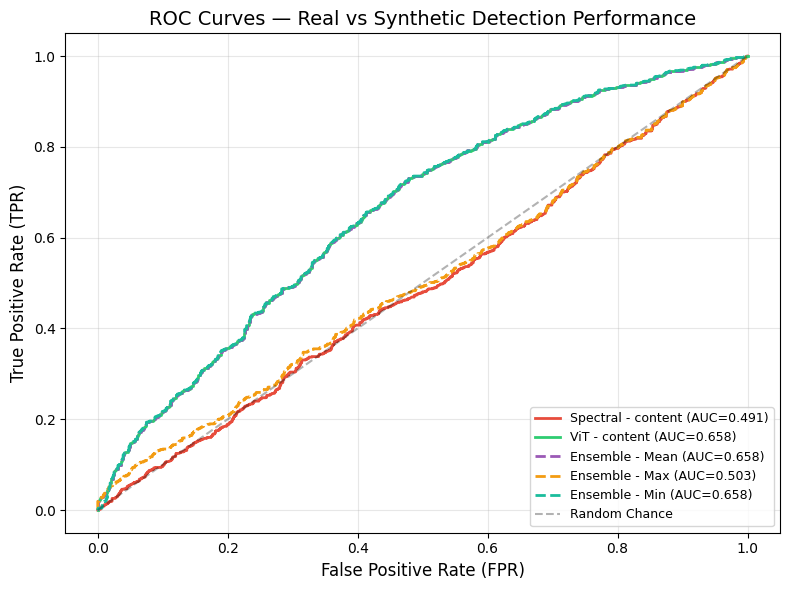

In [ ]:
# =================================================================
# ROC Curves — Visualizing Detector Performance (No CLIP)
# =================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import os
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

# Defined distinct colors for the remaining 5 detectors
colors = ["#e74c3c", "#2ecc71", "#9b59b6", "#f39c12", "#1abc9c"]

for (name, col), color in zip(all_detectors.items(), colors):
    # Filter out NaNs to ensure the plot renders correctly
    valid_mask = ~np.isnan(det_df[col].values)
    y_true_clean = y_true[valid_mask]
    y_scores_clean = det_df[col].values[valid_mask]

    if len(y_true_clean) == 0:
        continue

    # Calculate metrics
    fpr, tpr, _ = roc_curve(y_true_clean, y_scores_clean)
    auc_val = roc_auc_score(y_true_clean, y_scores_clean)

    # Use dashed lines for Ensemble models to differentiate them from single detectors
    linestyle = "--" if "Ensemble" in name else "-"

    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})",
            color=color, linestyle=linestyle, linewidth=2)

# Plot formatting
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random Chance")
ax.set_xlabel("False Positive Rate (FPR)", fontsize=12)
ax.set_ylabel("True Positive Rate (TPR)", fontsize=12)
ax.set_title("ROC Curves — Real vs Synthetic Detection Performance", fontsize=14)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()

# Save the plot
output_path = os.path.join(RESULTS_DIR, "roc_curves.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"ROC Curve plot saved to: {output_path}")

plt.show()

Distribution plot saved to: /content/results/score_distributions.png


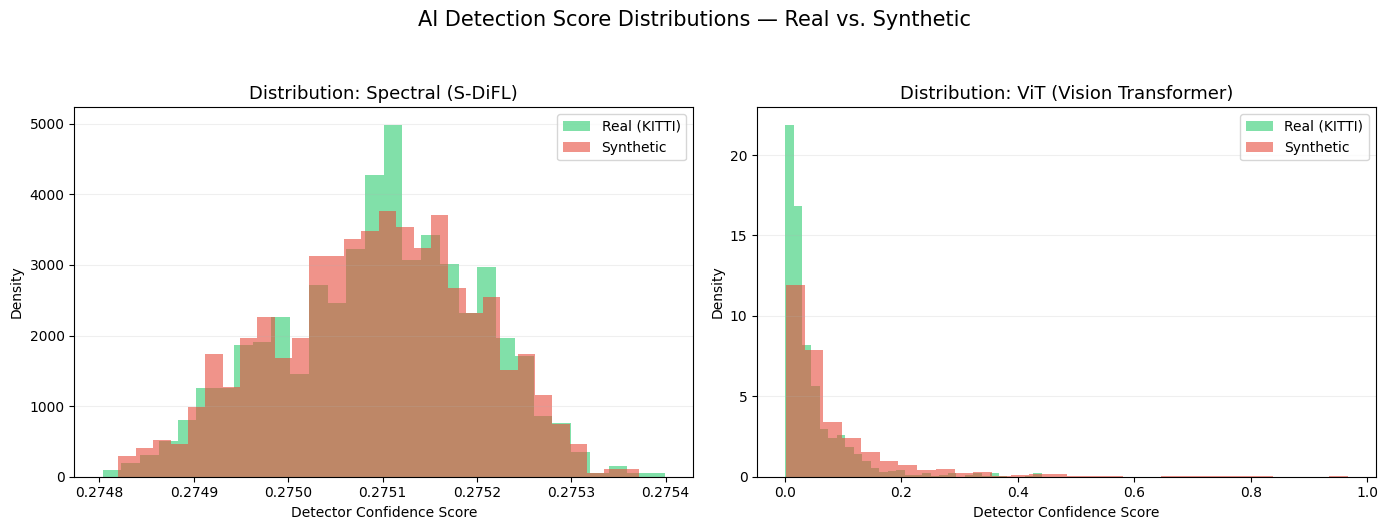

In [ ]:
# =================================================================
# Detector Score Distributions (No CLIP)
# =================================================================
import matplotlib.pyplot as plt
import os

# Adjust subplots to 1x2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# List of remaining detectors and their titles
detector_cols = [("spectral_score", "Spectral (S-DiFL)"),
                 ("vit_score", "ViT (Vision Transformer)")]

for ax, (col, title) in zip(axes, detector_cols):
    # Filter data by class
    real_scores = det_df[det_df["is_synthetic"] == 0][col].dropna()
    syn_scores  = det_df[det_df["is_synthetic"] == 1][col].dropna()

    # Plot histograms
    ax.hist(real_scores, bins=30, alpha=0.6, label="Real (KITTI)", color="#2ecc71", density=True)
    ax.hist(syn_scores, bins=30, alpha=0.6, label="Synthetic", color="#e74c3c", density=True)

    ax.set_title(f"Distribution: {title}", fontsize=13)
    ax.set_xlabel("Detector Confidence Score")
    ax.set_ylabel("Density")
    ax.grid(axis='y', alpha=0.2)
    ax.legend()

plt.suptitle("AI Detection Score Distributions — Real vs. Synthetic", fontsize=15, y=1.05)
plt.tight_layout()

# Save the updated distribution plot
dist_output_path = os.path.join(RESULTS_DIR, "score_distributions.png")
plt.savefig(dist_output_path, dpi=150, bbox_inches="tight")
print(f"Distribution plot saved to: {dist_output_path}")

plt.show()

In [ ]:
# =================================================================
# Final YOLOv11 Dataset Assembly (Real + Synthetic)
# =================================================================
import os
import glob
import shutil
from tqdm import tqdm

if DEBUG_MODE:
    print("DEBUG_MODE is ON — skipping YOLO dataset assembly and Drive export.")
    print("Set DEBUG_MODE = False and re-run to produce final artifacts.")
else:
    FINAL_DIR = "/content/final_dataset"

    # 1) Create directory structure
    for split in ["train", "val", "test"]:
        final_img_path = os.path.join(FINAL_DIR, "images", split)
        final_lbl_path = os.path.join(FINAL_DIR, "labels", split)
        os.makedirs(final_img_path, exist_ok=True)
        os.makedirs(final_lbl_path, exist_ok=True)

        # 2) Copy Real (Letterboxed) images and labels
        lb_img_src = os.path.join(LB_DIR, "images", split)
        lb_lbl_src = os.path.join(LB_DIR, "labels", split)

        real_files = glob.glob(os.path.join(lb_img_src, "*.png"))
        for f in tqdm(real_files, desc=f"Copying Real [{split}]", leave=False):
            shutil.copy2(f, final_img_path)

            # Copy corresponding label if it exists
            label_file = os.path.join(lb_lbl_src, os.path.basename(f).replace(".png", ".txt"))
            if os.path.exists(label_file):
                shutil.copy2(label_file, final_lbl_path)

        # 3) Copy Synthetic images and labels
        gen_img_src = os.path.join(OUTPUT_DIR, "images", split)
        gen_lbl_src = os.path.join(OUTPUT_DIR, "labels", split)

        syn_files = glob.glob(os.path.join(gen_img_src, "*.png"))
        for f in tqdm(syn_files, desc=f"Copying Synthetic [{split}]", leave=False):
            shutil.copy2(f, final_img_path)

            # Copy corresponding synthetic label
            label_file = os.path.join(gen_lbl_src, os.path.basename(f).replace(".png", ".txt"))
            if os.path.exists(label_file):
                shutil.copy2(label_file, final_lbl_path)

        n_imgs = len(glob.glob(os.path.join(final_img_path, "*.png")))
        n_lbls = len(glob.glob(os.path.join(final_lbl_path, "*.txt")))
        print(f"  [{split}] Finished: {n_imgs} images, {n_lbls} labels assembled.")

    # 4) Generate data.yaml with appropriate class mapping
    # KITTI classes 0-7 + your new Animal class
    yaml_content = f"""path: {FINAL_DIR}
train: images/train
val: images/val
test: images/test

names:
  0: Car
  1: Van
  2: Truck
  3: Pedestrian
  4: Person_sitting
  5: Cyclist
  6: Tram
  7: Misc
  {ANIMAL_CLASS_ID}: Animal
"""
    with open(os.path.join(FINAL_DIR, "data.yaml"), "w") as f:
        f.write(yaml_content)

    print(f"\ndata.yaml written to {FINAL_DIR}/data.yaml")
    print("Final YOLOv11 dataset successfully assembled.")

  [train] Finished: 700 images, 700 labels assembled.


  [val] Finished: 150 images, 150 labels assembled.


  [test] Finished: 150 images, 150 labels assembled.

data.yaml written to /content/final_dataset/data.yaml
Final YOLOv11 dataset successfully assembled.


In [ ]:
import os
import shutil
from tqdm import tqdm

# 1) Define the destination path in your Drive
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Autonomous_Car"

# Ensure the main project folder exists
os.makedirs(DRIVE_PROJECT_PATH, exist_ok=True)

# 2) Map all folders visible in your screenshot
# Format: "FolderNameInDrive": "/content/LocalFolderName"
folders_to_backup = {
    "datasets": "/content/datasets",
    "depth": "/content/depth",
    "final_dataset": "/content/final_dataset",
    "generated_images": "/content/generated",
    "letterboxed": "/content/letterboxed",
    "masks": "/content/masks",
    "analysis_results": "/content/results"
}

print(f"Starting complete backup to: {DRIVE_PROJECT_PATH}\n")

for folder_name, local_path in folders_to_backup.items():
    if os.path.exists(local_path):
        dest_path = os.path.join(DRIVE_PROJECT_PATH, folder_name)
        print(f"Syncing: {folder_name}...")

        try:
            # Copy local folder to Drive
            # dirs_exist_ok=True allows updating existing folders
            shutil.copytree(local_path, dest_path, dirs_exist_ok=True)

            # Verification: Count files in Drive vs Local
            local_count = len(os.listdir(local_path))
            print(f"  [SUCCESS] {folder_name} synced ({local_count} items).")
        except Exception as e:
            print(f"  [ERROR] Failed to sync {folder_name}: {e}")
    else:
        print(f"  [SKIP] {folder_name} folder not found at {local_path}.")

# 3) Individual file backup (if any files are loose in /content)
print("\nChecking for loose configuration files in /content...")
loose_files = ["data.yaml", "detection_scores.csv"]
for file_name in loose_files:
    local_file_path = os.path.join("/content", file_name)
    if os.path.exists(local_file_path):
        shutil.copy2(local_file_path, DRIVE_PROJECT_PATH)
        print(f"  [SUCCESS] {file_name} copied to Drive root.")

print("\n--- All Data Successfully Synced to Autonomous_Car ---")

Starting complete backup to: /content/drive/MyDrive/Autonomous_Car

Syncing: datasets...
  [SUCCESS] datasets synced (1 items).
Syncing: depth...
  [SUCCESS] depth synced (2 items).
Syncing: final_dataset...
  [SUCCESS] final_dataset synced (3 items).
Syncing: generated_images...
  [SUCCESS] generated_images synced (2 items).
Syncing: letterboxed...
  [SUCCESS] letterboxed synced (2 items).
Syncing: masks...
  [SUCCESS] masks synced (2 items).
Syncing: analysis_results...
  [SUCCESS] analysis_results synced (4 items).

Checking for loose configuration files in /content...

--- All Data Successfully Synced to Autonomous_Car ---


In [ ]:
import os

def count_files_recursively(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

print(f"Verifying files in Google Drive ({DRIVE_PROJECT_PATH}):\n")
for folder in os.listdir(DRIVE_PROJECT_PATH):
    folder_path = os.path.join(DRIVE_PROJECT_PATH, folder)
    if os.path.isdir(folder_path):
        total_files = count_files_recursively(folder_path)
        print(f"Folder: {folder:20s} | Total Files (including subfolders): {total_files}")

Verifying files in Google Drive (/content/drive/MyDrive/Autonomous_Car):

Folder: Notebooks            | Total Files (including subfolders): 2
Folder: kitti_baseline       | Total Files (including subfolders): 14963
Folder: visuals              | Total Files (including subfolders): 4
Folder: kitti_letterboxed    | Total Files (including subfolders): 2000
Folder: synthetic_data       | Total Files (including subfolders): 1876
Folder: analysis_results     | Total Files (including subfolders): 4
Folder: yolo_dataset_final   | Total Files (including subfolders): 2001
Folder: datasets             | Total Files (including subfolders): 14963
Folder: depth                | Total Files (including subfolders): 1000
Folder: final_dataset        | Total Files (including subfolders): 2001
Folder: generated_images     | Total Files (including subfolders): 1876
Folder: letterboxed          | Total Files (including subfolders): 2000
Folder: masks                | Total Files (including subfolders): 10